In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"


In [2]:
import torch
from torchvision.transforms import v2
from medmnist import PathMNIST

val_transform_cpu = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

val_transform = v2.Compose([
    v2.Normalize(mean=(0.5,0.5,0.5),std=(0.5,0.5,0.5))
])

val_dataset = PathMNIST(root="./data/",split="val",transform=val_transform_cpu,download=True,size=64)

n_labels = len(val_dataset.info["label"].items())

print("CUDA Blocking Active:", os.environ.get("CUDA_LAUNCH_BLOCKING") == "1")

CUDA Blocking Active: True


In [3]:
import os
from models.cross_predictor_hybrid import Predictor

prev_model_type = "cross_predictor_hybrid"
model_type = "full_" + prev_model_type

prev_model_id = "2.2"
model_id = "2.4"

notes = "implemented heavier augments"

model_save_folder = f"model_weights/finetuning/{model_type}/{model_id}"

os.makedirs(model_save_folder,exist_ok=True)

freeze_encoder = False
is_linear_probe = True

model = Predictor(n_labels=n_labels)
model.load_state_dict(torch.load(f"model_weights/checkpoints/{prev_model_type}/{prev_model_id}/model_epoch_100.pt"))

if freeze_encoder == True:
    for name, param in model.autoencoder.named_parameters():
        param.requires_grad = False

print(model)


Predictor(
  (autoencoder): AutoEncoder(
    (patcher): CNN(
      (conv): Conv2d(3, 1024, kernel_size=(4, 4), stride=(4, 4))
      (fc): Linear(in_features=1024, out_features=512, bias=True)
      (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
    )
    (encoder): Encoder(
      (transformer_blocks): Sequential(
        (0): TransformerBlock(
          (mha): MultiHeadAttention(
            (linear_qkv): Linear(in_features=512, out_features=1536, bias=True)
            (linear_out): Linear(in_features=512, out_features=512, bias=True)
          )
          (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
          (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
          (ff): FeedForward(
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
            (gelu): GELU(approximate='none')
          )
          (droppath1

In [4]:
model_no_parameters = sum(param.numel() for param in model.parameters())
print(f"Total Parameters in {model_type} : {model_no_parameters}")

Total Parameters in full_cross_predictor_hybrid : 28954633


In [5]:
import math
# since the encoder is unfrozen the linear probe get heavier augmentation that with probe training.

train_transform_cpu = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

# whole patch is 16x16
# where 64x64 image and 4x4 kernel and stride is 4x4
pad=12
crop_with_padding_shift = (64+(2*pad))
extra_pad = math.ceil(((crop_with_padding_shift * math.sqrt(2))-crop_with_padding_shift)/2) + 2
total_pad = pad+extra_pad
train_transform = v2.Compose([
    v2.RandomHorizontalFlip(0.5),
    v2.RandomVerticalFlip(0.5),
    v2.Pad(padding=total_pad,padding_mode="reflect"),
    v2.ElasticTransform(alpha=15.0,sigma=3.0),
    v2.RandomRotation(degrees=(0,360),interpolation=v2.InterpolationMode.BILINEAR),
    v2.CenterCrop(size=(crop_with_padding_shift,crop_with_padding_shift)),
    v2.RandomCrop(size=(64,64)),
    v2.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.4,
        hue=0.1
    ),
    v2.GaussianBlur(kernel_size=(3,3),sigma=(0.1,4.0)),
    v2.GaussianNoise(sigma=0.01),
    v2.Normalize(mean=(0.5,0.5,0.5),std=(0.5,0.5,0.5)),
])

train_dataset = PathMNIST(root="./data/",split="train",transform=train_transform_cpu,download=True,size=64)

In [6]:
from torch.utils.data import DataLoader
from data_augments import MixerCollate

mc = MixerCollate(n_labels=n_labels)

num_workers = 4

train_batch_size = 128
val_batch_size = 128
effective_batch = 256
if 256 % train_batch_size != 0:
    raise ValueError()

train_dl = DataLoader(
    train_dataset,
    batch_size= train_batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True,
    collate_fn=mc.collate_fn
)

val_dl = DataLoader(
    val_dataset,
    batch_size = val_batch_size,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True
)


In [7]:
import math
from torch import nn
from torch import optim

grad_acc = max(1,(256//train_batch_size))
steps_per_epoch = len(train_dl)

epochs = 100
warm_up_epochs = 5
checkpointing_rate = 10

warm_up_steps = warm_up_epochs*steps_per_epoch
cosine_steps = (epochs - warm_up_epochs)*steps_per_epoch

# lr is reduce to prevent gradient explosion
base_lr = 1.5e-4
max_lr = base_lr * (effective_batch/256)
lr_decay = 0.75

betas = (0.9, 0.999)
weight_decay = 0.05

adamw_config = []

adamw_config.append({"params":model.predictor.parameters(),"lr":max_lr,"betas":betas,"weight_decay":weight_decay}) 
if not freeze_encoder:
    block_len = len(model.autoencoder.encoder.transformer_blocks)
    current_lr = base_lr

    for i in range(block_len):
        current_lr *= lr_decay
        adamw_config.append({"params":model.autoencoder.encoder.transformer_blocks[block_len-i-1].parameters(),"lr":(current_lr * (effective_batch/256)),"betas":betas,"weight_decay":weight_decay}) 

    current_lr *= lr_decay
    adamw_config.append({"params":model.autoencoder.patcher.parameters(),"lr":(current_lr * (effective_batch/256)),"betas":betas,"weight_decay":weight_decay}) 

optimiser = optim.AdamW(adamw_config)

loss = nn.CrossEntropyLoss()

# start at minimum and go up
warmup_scheduler = optim.lr_scheduler.LinearLR(
    optimiser,
    start_factor=0.1,
    end_factor=1.0,
    total_iters=warm_up_steps
)
cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimiser,
    T_max=cosine_steps,
)
scheduler = optim.lr_scheduler.SequentialLR(
    optimiser,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[warm_up_steps]
)


In [8]:
import os
from training_functions import finetune,test
from tqdm.notebook import tqdm
import mlflow
import time
import csv

log_folder_path = f"logs/finetuning/{model_type}/{model_id}"

os.makedirs(log_folder_path,exist_ok=True)

log_file_path = f"{log_folder_path}/finetuning_log_{int(time.time())}.csv"

device = "cuda" if torch.cuda.is_available() else "cpu"

mlflow.set_tracking_uri("http://192.168.1.36:5000")
mlflow.set_experiment(model_type)
with mlflow.start_run(run_name=model_id):

    mlflow_dataset = mlflow.data.numpy_dataset.from_numpy(
        features=train_dataset.imgs,
        targets=train_dataset.labels
    )
    mlflow.log_input(mlflow_dataset, context="training")

    mlflow.log_params({
        "training_batch_size":train_batch_size,
        "effective_batch":effective_batch,
        "base_lr":base_lr,
        "max_lr":max_lr,
        "epochs":epochs,
        "warmup_epochs":warm_up_epochs,
        "steps_per_epoch":steps_per_epoch,
        "gradient_accumulation":grad_acc,
        "frozen_encoder":freeze_encoder,
        "parameter_count":model_no_parameters,
    })

    mlflow.set_tags({
        "stage":"finetuning",
        "model_id": model_id,
        "notes":notes,
    })

    mlflow.log_text(str(train_transform),"training_augmentations.txt")
    mlflow.log_text(str(optimiser),"optimiser_config.txt")
    mlflow.log_text(str(scheduler.__dict__),"scheduler_config.txt")
    loss_config = {
        "loss_type":type(loss).__name__,
        "label_smoothing":getattr(loss,"label_smoothing",0.0),
        "ignore_index": getattr(loss, "ignore_index", -100),
        "reduction": getattr(loss, "reduction", "mean"),
    }
    mlflow.log_text(str(loss_config),"loss_config.txt")
    

    with open(log_file_path, mode="w", newline="") as f:
        prev_train_loss = None
        prev_val_loss = None
        writer = csv.writer(f)
        csv_header = ["epoch", "train_loss", "val_loss","train_delta","val_delta","train_acc","val_acc","train_auc","val_auc","current_lr"]
        writer.writerow(csv_header)

        model = model.to(device)
        torch.set_float32_matmul_precision('high')
        model = torch.compile(model)

        with tqdm(range(epochs),desc="Epochs") as bar:
            for epoch in bar:
                
                train_delta = val_delta = 0.0

                train_loss,train_acc,train_auc = finetune(model, device, train_dl, train_transform, loss, optimiser, epoch, scheduler, grad_acc)

                current_lr = optimiser.param_groups[0]['lr']
                
                val_loss,val_acc,val_auc = test(model, device, val_dl, val_transform, loss,epoch)

                train_delta = train_loss - prev_train_loss  if prev_train_loss is not None else 0.0
                val_delta = val_loss - prev_val_loss if prev_val_loss is not None else 0.0

                prev_train_loss = train_loss
                prev_val_loss = val_loss

                mlflow_metrics = {
                    "train_loss":train_loss,
                    "val_loss":val_loss,
                    "train_delta":train_delta,
                    "val_delta":val_delta,
                    "train_acc":train_acc,
                    "val_acc":val_acc,
                    "train_auc":train_auc,
                    "val_auc":val_auc,
                    "current_lr":current_lr,
                }
                postfix_metrics = { k:f"{v:.3g}" for k,v in mlflow_metrics.items()}
                
                bar.set_postfix(postfix_metrics)
                mlflow.log_metrics(mlflow_metrics,step=(epoch+1))

                csv_arr = [epoch+1,train_loss,val_loss,train_delta,val_delta,train_acc,val_acc,train_auc,val_auc,current_lr]
                writer.writerow(csv_arr)
                f.flush()

                if (epoch+1) % checkpointing_rate == 0:
                    torch.save(model._orig_mod.state_dict() if hasattr(model, '_orig_mod') else model.state_dict(),f"{model_save_folder}/model_epoch_{epoch+1}.pt")

Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1: Training:   0%|          | 0/704 [00:00<?, ?it/s]

W0905 19:40:55.298000 11321 torch/_inductor/utils.py:1953] [0/0] Not enough SMs to use max_autotune_gemm mode
/mnt/sdc/Hasan/Documents/My Documents/Code/MAE-Model-MedMNIST-Predictor/.venv/lib64/python3.14/site-packages/torch/optim/lr_scheduler.py:1194: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch 1: Validation:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2: Training:   0%|          | 0/704 [00:00<?, ?it/s]

...

Epoch 99: Training:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 99: Validation:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 100: Training:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 100: Validation:   0%|          | 0/79 [00:00<?, ?it/s]

🏃 View run 2.4 at: http://192.168.1.36:5000/#/experiments/6/runs/a9cc5f15465a4fe8b29b3f1f7574602d
🧪 View experiment at: http://192.168.1.36:5000/#/experiments/6


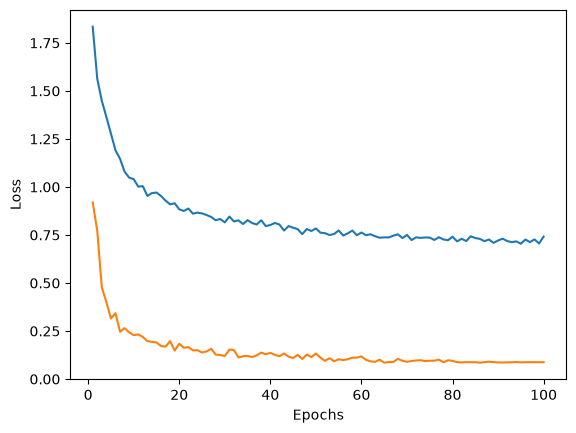

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import time

graph_save_folder = f"graphs/finetuning/{model_type}/{model_id}"

os.makedirs(graph_save_folder,exist_ok=True)

dataframe = pd.read_csv(log_file_path)

plt.plot(dataframe["epoch"],dataframe["train_loss"])
plt.plot(dataframe["epoch"],dataframe["val_loss"])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.savefig(f"{graph_save_folder}/train_loss_{int(time.time())}.png")
plt.show()
plt.close()